# Kalshi Market Time Series Construction
Process all markets & trades parquet files to build bid-ask spread and last price time series.

In [7]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt


REPO_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
PATH = REPO_ROOT / "data" / "kalshi"
MARKETS_DIR = PATH / "markets"
TRADES_DIR = PATH / "trades"
OUTPUT_DIR = PATH / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

market_files = sorted(MARKETS_DIR.glob("*.parquet"))
trade_files = sorted(TRADES_DIR.glob("*.parquet"))
print(f"Market files: {len(market_files)}, Trade files: {len(trade_files)}")

Market files: 769, Trade files: 7214


## 1. Process Markets — extract bid/ask/spread/last_price per ticker over time
We process in chunks to avoid OOM, keeping only the columns we need.

In [8]:
MARKET_COLS = ["ticker", "yes_bid", "yes_ask", "no_bid", "no_ask", "last_price", "open_time", "close_time", "status", "volume"]

chunks = []
for i, f in enumerate(market_files):
    df = pd.read_parquet(f, columns=MARKET_COLS)
    chunks.append(df)
    if (i + 1) % 100 == 0:
        print(f"  loaded {i+1}/{len(market_files)} market files")

markets = pd.concat(chunks, ignore_index=True)
del chunks
print(f"Total market rows: {len(markets):,}")
markets.head()

  loaded 100/769 market files
  loaded 200/769 market files
  loaded 300/769 market files
  loaded 400/769 market files
  loaded 500/769 market files
  loaded 600/769 market files
  loaded 700/769 market files
Total market rows: 7,682,445


,ticker,yes_bid,yes_ask,no_bid,no_ask,last_price,open_time,close_time,status,volume
0,KXMVESPORTSMULTIGAMEEXTENDED-S2025791D973FCDE-...,0,0,100,100,0,2025-11-23 18:51:48.622007+00:00,2025-12-07 23:00:00+00:00,active,0
1,KXMVESPORTSMULTIGAMEEXTENDED-S202541FEC413CA1-...,0,0,100,100,0,2025-11-23 18:51:48.177164+00:00,2025-12-07 18:00:00+00:00,active,0
2,KXMVESPORTSMULTIGAMEEXTENDED-S2025AF0C3DAAC7F-...,0,0,100,100,0,2025-11-23 18:51:47.066584+00:00,2025-12-08 01:20:00+00:00,active,0
3,KXMVESPORTSMULTIGAMEEXTENDED-S202559827ED1152-...,0,0,100,100,0,2025-11-23 18:51:46.970317+00:00,2025-12-07 18:00:00+00:00,active,0
4,KXMVESPORTSMULTIGAMEEXTENDED-S20252F848F1C785-...,0,0,100,100,0,2025-11-23 18:51:46.963903+00:00,2025-12-09 01:15:00+00:00,active,0


In [9]:
# Compute spreads
markets["yes_spread"] = markets["yes_ask"] - markets["yes_bid"]
markets["no_spread"] = markets["no_ask"] - markets["no_bid"]

# Parse times
markets["open_time"] = pd.to_datetime(markets["open_time"], utc=True)
markets["close_time"] = pd.to_datetime(markets["close_time"], utc=True)

markets.head()

,ticker,yes_bid,yes_ask,no_bid,no_ask,last_price,open_time,close_time,status,volume,yes_spread,no_spread
0,KXMVESPORTSMULTIGAMEEXTENDED-S2025791D973FCDE-...,0,0,100,100,0,2025-11-23 18:51:48.622007+00:00,2025-12-07 23:00:00+00:00,active,0,0,0
1,KXMVESPORTSMULTIGAMEEXTENDED-S202541FEC413CA1-...,0,0,100,100,0,2025-11-23 18:51:48.177164+00:00,2025-12-07 18:00:00+00:00,active,0,0,0
2,KXMVESPORTSMULTIGAMEEXTENDED-S2025AF0C3DAAC7F-...,0,0,100,100,0,2025-11-23 18:51:47.066584+00:00,2025-12-08 01:20:00+00:00,active,0,0,0
3,KXMVESPORTSMULTIGAMEEXTENDED-S202559827ED1152-...,0,0,100,100,0,2025-11-23 18:51:46.970317+00:00,2025-12-07 18:00:00+00:00,active,0,0,0
4,KXMVESPORTSMULTIGAMEEXTENDED-S20252F848F1C785-...,0,0,100,100,0,2025-11-23 18:51:46.963903+00:00,2025-12-09 01:15:00+00:00,active,0,0,0


In [10]:
# Save full processed markets table
markets.to_parquet(os.path.join(OUTPUT_DIR, "all_markets.parquet"), index=False)
print("Saved all_markets.parquet")

Saved all_markets.parquet


## 2. Process Trades — last price time series from actual trade executions

In [11]:
TRADE_COLS = ["ticker", "yes_price", "no_price", "count", "taker_side", "created_time"]

# Trades are ~72M rows — process in batches and write intermediate parquets
BATCH = 500
batch_paths = []

for batch_start in range(0, len(trade_files), BATCH):
    batch_end = min(batch_start + BATCH, len(trade_files))
    chunks = []
    for f in trade_files[batch_start:batch_end]:
        chunks.append(pd.read_parquet(f, columns=TRADE_COLS))
    batch_df = pd.concat(chunks, ignore_index=True)
    batch_df["created_time"] = pd.to_datetime(batch_df["created_time"], utc=True)
    out = os.path.join(OUTPUT_DIR, f"trades_batch_{batch_start}.parquet")
    batch_df.to_parquet(out, index=False)
    batch_paths.append(out)
    print(f"  batch {batch_start}-{batch_end}: {len(batch_df):,} trades")
    del chunks, batch_df

print(f"Wrote {len(batch_paths)} trade batches")

  batch 0-500: 5,000,000 trades
  batch 500-1000: 5,000,000 trades
  batch 1000-1500: 5,000,000 trades
  batch 1500-2000: 5,000,000 trades
  batch 2000-2500: 5,000,000 trades
  batch 2500-3000: 5,000,000 trades
  batch 3000-3500: 5,000,000 trades
  batch 3500-4000: 5,000,000 trades
  batch 4000-4500: 5,000,000 trades
  batch 4500-5000: 5,000,000 trades
  batch 5000-5500: 5,000,000 trades
  batch 5500-6000: 5,000,000 trades
  batch 6000-6500: 5,000,000 trades
  batch 6500-7000: 4,994,741 trades
  batch 7000-7214: 2,140,000 trades
Wrote 15 trade batches


In [12]:
# Combine all trade batches
trades = pd.concat([pd.read_parquet(p) for p in batch_paths], ignore_index=True)
trades.sort_values("created_time", inplace=True)
trades.reset_index(drop=True, inplace=True)
print(f"Total trade rows: {len(trades):,}")
trades.head()

Total trade rows: 72,134,741


,ticker,yes_price,no_price,count,taker_side,created_time
0,HOME-21JUN-T750,76,24,5,yes,2021-06-30 20:09:14.185137+00:00
1,HOME-21JUN-T750,76,24,10,yes,2021-07-01 14:53:12.675773+00:00
2,CPI-21JUN-T0.6,17,83,100,yes,2021-07-01 14:53:38.613666+00:00
3,GDP-21JUN30-T6.0,81,19,20,yes,2021-07-01 14:54:00.422415+00:00
4,TRDDEFCN-21MAY-T30,34,66,100,yes,2021-07-01 14:54:11.235167+00:00


In [13]:
trades.to_parquet(os.path.join(OUTPUT_DIR, "all_trades.parquet"), index=False)
print("Saved all_trades.parquet")

# Clean up batch files
for p in batch_paths:
    os.remove(p)

Saved all_trades.parquet


## 3. Build per-ticker time series
For each ticker, merge the snapshot-level bid/ask from markets with the trade-level last prices.

In [14]:
TRADE_COLS = ["ticker", "yes_price", "no_price", "count", "taker_side", "created_time"]

ts_chunks = []

for i, f in enumerate(trade_files):
    df = pd.read_parquet(f, columns=TRADE_COLS)
    df["created_time"] = pd.to_datetime(df["created_time"], utc=True)
    df.set_index("created_time", inplace=True)
    
    # Resample per ticker within this chunk
    g = df.groupby("ticker")["yes_price"].resample("1min").agg(["last", "mean", "count"]).dropna(subset=["last"])
    ts_chunks.append(g.reset_index())
    
    if (i + 1) % 500 == 0:
        # Flush to disk periodically to free memory
        part = pd.concat(ts_chunks, ignore_index=True)
        part.to_parquet(os.path.join(OUTPUT_DIR, f"ts_part_{i}.parquet"), index=False)
        ts_chunks = []
        print(f"  flushed at file {i+1}/{len(trade_files)}")

# Final flush
if ts_chunks:
    part = pd.concat(ts_chunks, ignore_index=True)
    part.to_parquet(os.path.join(OUTPUT_DIR, "ts_part_final.parquet"), index=False)
    del ts_chunks, part

print("Done chunked resample. Now merging parts...")

# Reload parts and re-aggregate (since a ticker may span multiple files)
parts = [pd.read_parquet(f) for f in glob.glob(os.path.join(OUTPUT_DIR, "ts_part_*.parquet"))]
trade_ts = pd.concat(parts, ignore_index=True)
del parts

# Re-aggregate overlapping (ticker, minute) rows across chunks
trade_ts = (
    trade_ts.groupby(["ticker", "created_time"])
    .agg(last_yes_price=("last", "last"), vwap_yes=("mean", "mean"), n_trades=("count", "sum"))
    .reset_index()
)

trade_ts.to_parquet(os.path.join(OUTPUT_DIR, "trade_timeseries_1min.parquet"), index=False)
print(f"Trade time series rows: {len(trade_ts):,}")

# Cleanup temp parts
for f in glob.glob(os.path.join(OUTPUT_DIR, "ts_part_*.parquet")):
    os.remove(f)

  flushed at file 500/7214
  flushed at file 1000/7214
  flushed at file 1500/7214
  flushed at file 2000/7214
  flushed at file 2500/7214
  flushed at file 3000/7214
  flushed at file 3500/7214
  flushed at file 4000/7214
  flushed at file 4500/7214
  flushed at file 5000/7214
  flushed at file 5500/7214
  flushed at file 6000/7214
  flushed at file 6500/7214
  flushed at file 7000/7214
Done chunked resample. Now merging parts...
Trade time series rows: 21,919,678


In [15]:
trade_ts.to_parquet(os.path.join(OUTPUT_DIR, "trade_timeseries_1min.parquet"), index=False)
print("Saved trade_timeseries_1min.parquet")

Saved trade_timeseries_1min.parquet


## 4. Quick summary stats & sanity checks

In [16]:
print("=== Markets ===")
print(f"Unique tickers: {markets['ticker'].nunique():,}")
print(f"Date range: {markets['open_time'].min()} -> {markets['close_time'].max()}")
print(f"\nYes spread stats:")
print(markets["yes_spread"].describe())
print(f"\nNo spread stats:")
print(markets["no_spread"].describe())

print("\n=== Trades ===")
print(f"Unique tickers traded: {trades['ticker'].nunique():,}")
print(f"Date range: {trades.index.min()} -> {trades.index.max()}")

=== Markets ===
Unique tickers: 7,682,445
Date range: 2021-06-30 14:00:00+00:00 -> 2099-08-01 04:59:00+00:00

Yes spread stats:
count    7.682445e+06
mean     5.540981e+01
std      4.876593e+01
min      0.000000e+00
25%      0.000000e+00
50%      9.900000e+01
75%      1.000000e+02
max      1.000000e+02
Name: yes_spread, dtype: float64

No spread stats:
count    7.682445e+06
mean     5.540981e+01
std      4.876593e+01
min      0.000000e+00
25%      0.000000e+00
50%      9.900000e+01
75%      1.000000e+02
max      1.000000e+02
Name: no_spread, dtype: float64

=== Trades ===
Unique tickers traded: 586,025
Date range: 0 -> 72134740


Most traded ticker: PRES-2024-DJT


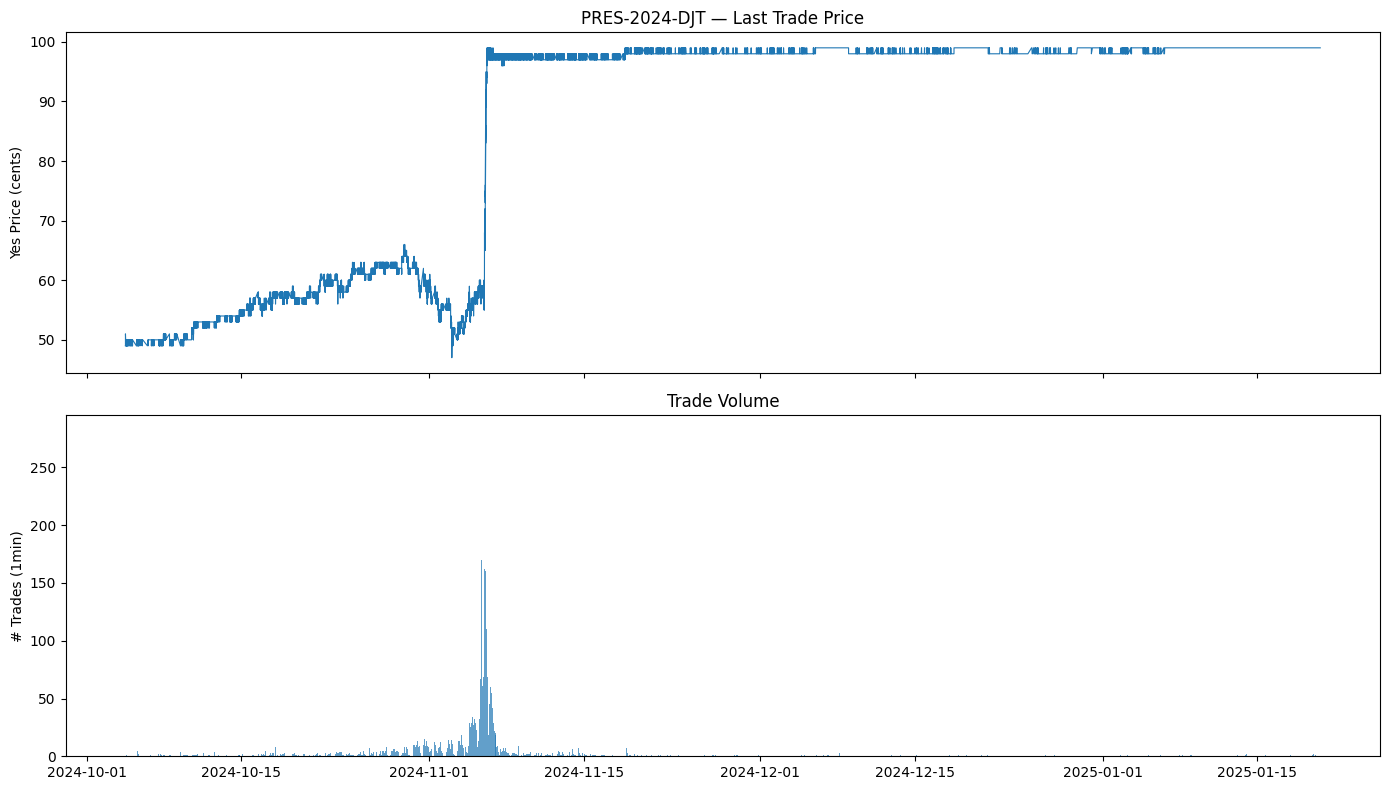


Market snapshot — yes_bid: 99, yes_ask: 100, yes_spread: 1
                  no_bid: 0, no_ask: 1, no_spread: 1


In [17]:


# Pick ticker with most trades
top_ticker = trades.groupby("ticker").size().idxmax()
print(f"Most traded ticker: {top_ticker}")

ts = trade_ts[trade_ts["ticker"] == top_ticker].set_index("created_time")
mkt = markets[markets["ticker"] == top_ticker].iloc[0]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(ts.index, ts["last_yes_price"], lw=0.8)
axes[0].set_ylabel("Yes Price (cents)")
axes[0].set_title(f"{top_ticker} — Last Trade Price")

axes[1].bar(ts.index, ts["n_trades"], width=0.0007, alpha=0.7)
axes[1].set_ylabel("# Trades (1min)")
axes[1].set_title("Trade Volume")

plt.tight_layout()
plt.show()

print(f"\nMarket snapshot — yes_bid: {mkt['yes_bid']}, yes_ask: {mkt['yes_ask']}, yes_spread: {mkt['yes_spread']}")
print(f"                  no_bid: {mkt['no_bid']}, no_ask: {mkt['no_ask']}, no_spread: {mkt['no_spread']}")

# Exploratory Data Analysis

In [34]:
# count the total number of tickers
df = pd.read_parquet(os.path.join(OUTPUT_DIR, "trade_timeseries_1min.parquet"))
df["approx_volume"] = df["vwap_yes"] * df["n_trades"]
df.head()

,ticker,created_time,last_yes_price,vwap_yes,n_trades,approx_volume
0,-23MAR-T2,2023-03-12 21:40:00+00:00,15.0,14.5,2,29.0
1,-23MAR-T2,2023-03-12 22:10:00+00:00,20.0,19.5,2,39.0
2,-23MAR-T2,2023-03-12 22:11:00+00:00,21.0,21.5,2,43.0
3,-23MAR-T2,2023-03-13 17:28:00+00:00,20.0,20.0,1,20.0
4,-23MAR-T2,2023-03-13 20:03:00+00:00,13.0,14.0,2,28.0


In [26]:

print(f"Shape: {df.shape}")
print(f"Unique tickers: {df['ticker'].nunique():,}")
print(f"Date range: {df['created_time'].min()} → {df['created_time'].max()}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nNull counts:\n{df.isnull().sum()}")
print(f"\nBasic stats:")
df[["last_yes_price", "vwap_yes", "n_trades"]].describe()

Shape: (21919678, 5)
Unique tickers: 586,025
Date range: 2021-06-30 20:09:00+00:00 → 2025-11-25 22:00:00+00:00

Column dtypes:
ticker                         object
created_time      datetime64[ns, UTC]
last_yes_price                float64
vwap_yes                      float64
n_trades                        int64
dtype: object

Null counts:
ticker            0
created_time      0
last_yes_price    0
vwap_yes          0
n_trades          0
dtype: int64

Basic stats:


,last_yes_price,vwap_yes,n_trades
count,2.191968e+07,2.191968e+07,2.191968e+07
mean,4.122793e+01,4.122714e+01,3.290867e+00
std,2.878377e+01,2.870614e+01,1.161800e+01
min,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.500000e+01,1.500000e+01,1.000000e+00
50%,3.900000e+01,3.900000e+01,1.000000e+00
75%,6.300000e+01,6.300000e+01,2.000000e+00
max,9.900000e+01,9.900000e+01,2.018000e+03


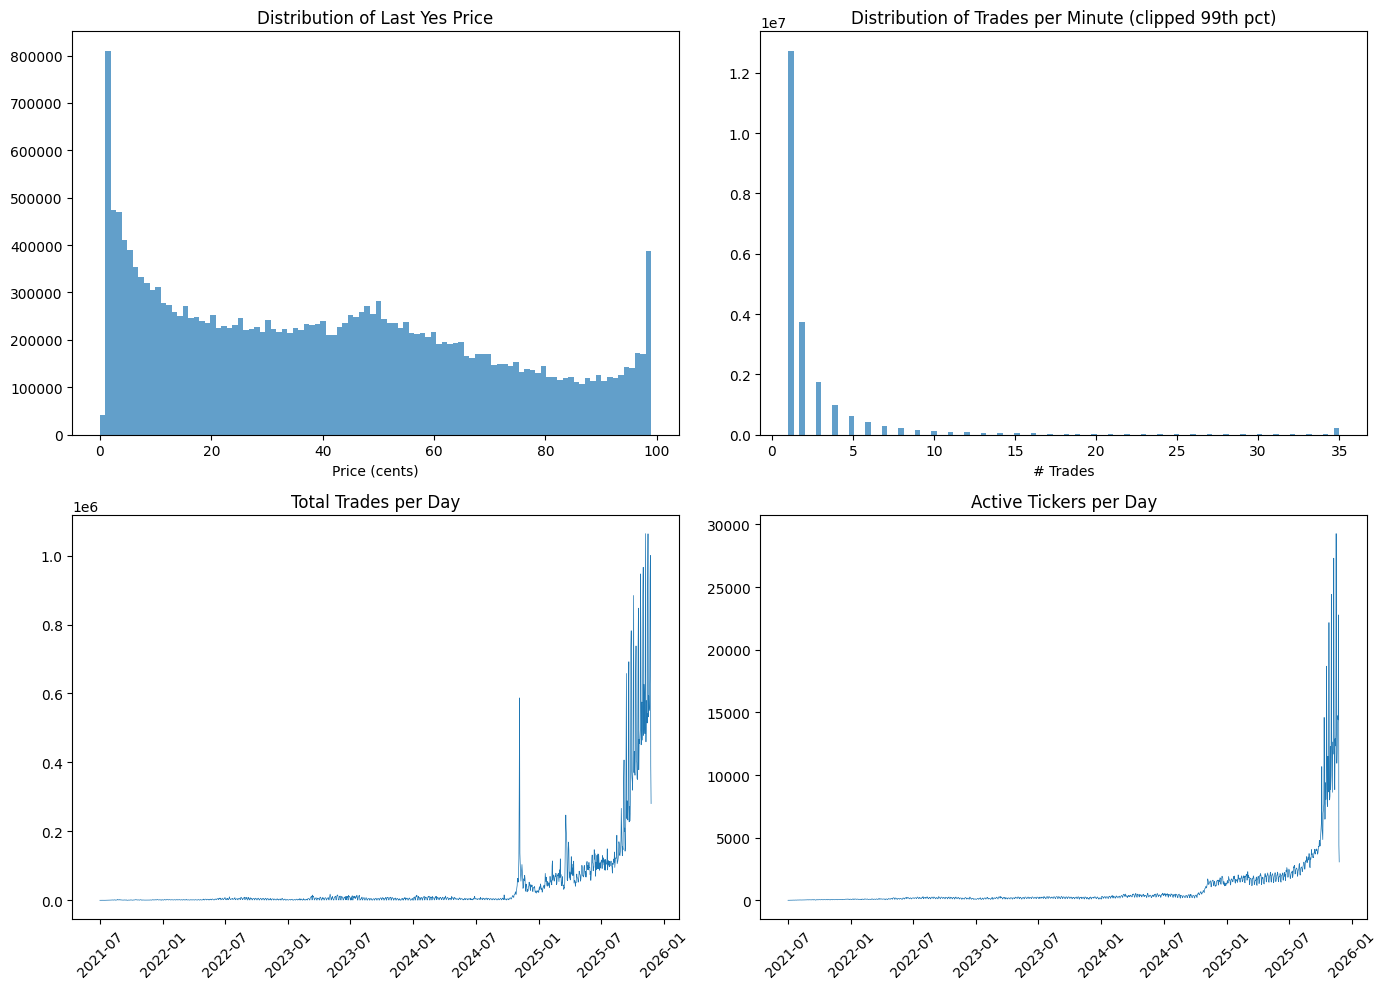

In [27]:
# Distribution of last_yes_price
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["last_yes_price"], bins=100, edgecolor="none", alpha=0.7)
axes[0, 0].set_title("Distribution of Last Yes Price")
axes[0, 0].set_xlabel("Price (cents)")

axes[0, 1].hist(df["n_trades"].clip(upper=df["n_trades"].quantile(0.99)), bins=100, edgecolor="none", alpha=0.7)
axes[0, 1].set_title("Distribution of Trades per Minute (clipped 99th pct)")
axes[0, 1].set_xlabel("# Trades")

# Trades per day
daily = df.groupby(df["created_time"].dt.date)["n_trades"].sum()
axes[1, 0].plot(daily.index, daily.values, lw=0.5)
axes[1, 0].set_title("Total Trades per Day")
axes[1, 0].tick_params(axis="x", rotation=45)

# Active tickers per day
active = df.groupby(df["created_time"].dt.date)["ticker"].nunique()
axes[1, 1].plot(active.index, active.values, lw=0.5)
axes[1, 1].set_title("Active Tickers per Day")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Top 20 tickers by total trades:
ticker
PRES-2024-DJT                  287494
PRES-2024-KH                   213961
KXMLB-25-LAD                   149605
KXNBA-25-IND                   103818
KXNFLGAME-25OCT02SFLA-SF        91859
KXNFLGAME-25SEP28GBDAL-DAL      87729
KXMLB-25-TOR                    87246
KXNFLGAME-25OCT06KCJAC-JAC      81846
KXNFLGAME-25OCT02SFLA-LA        78836
KXNFLGAME-25OCT06KCJAC-KC       78116
KXNFLGAME-25OCT20TBDET-TB       75915
KXMARMAD-25-FL                  72592
KXNFLGAME-25SEP28GBDAL-GB       72016
KXNBA-25-OKC                    69502
KXNFLGAME-25OCT13BUFATL-BUF     69474
KXNFLGAME-25SEP08MINCHI-MIN     68981
KXNFLGAME-25OCT12DETKC-DET      68547
KXNFLGAME-25SEP22DETBAL-DET     67852
KXNFLGAME-25NOV03ARIDAL-DAL     65488
KXNFLGAME-25OCT09PHINYG-PHI     64699
Name: n_trades, dtype: int64


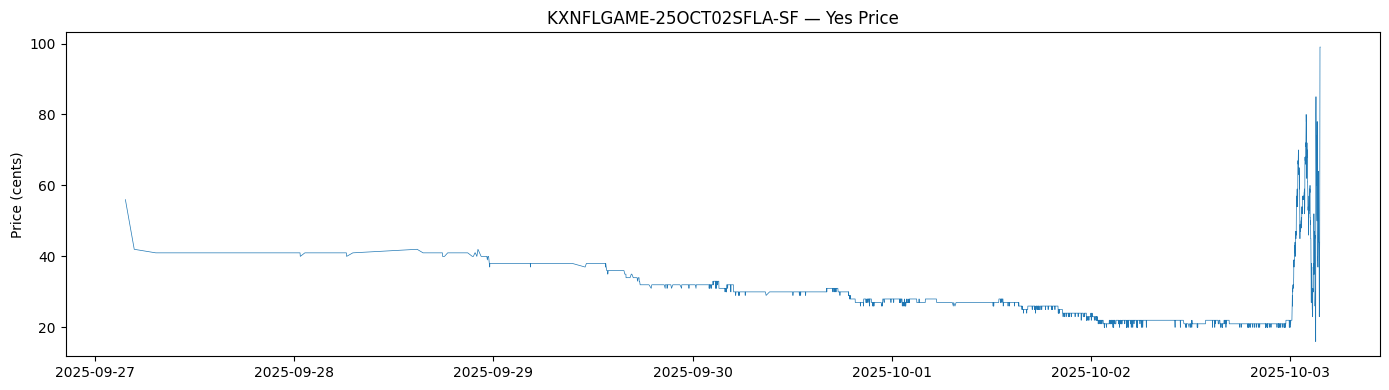

In [31]:
# Top 20 most traded tickers
top20 = df.groupby("ticker")["n_trades"].sum().nlargest(20)
print("Top 20 tickers by total trades:")
print(top20)

# Plot
top_ticker = top20.index[4]
ts = df[df["ticker"] == top_ticker].set_index("created_time").sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts.index, ts["last_yes_price"], lw=0.5)
ax.set_title(f"{top_ticker} — Yes Price")
ax.set_ylabel("Price (cents)")
plt.tight_layout()
plt.show()

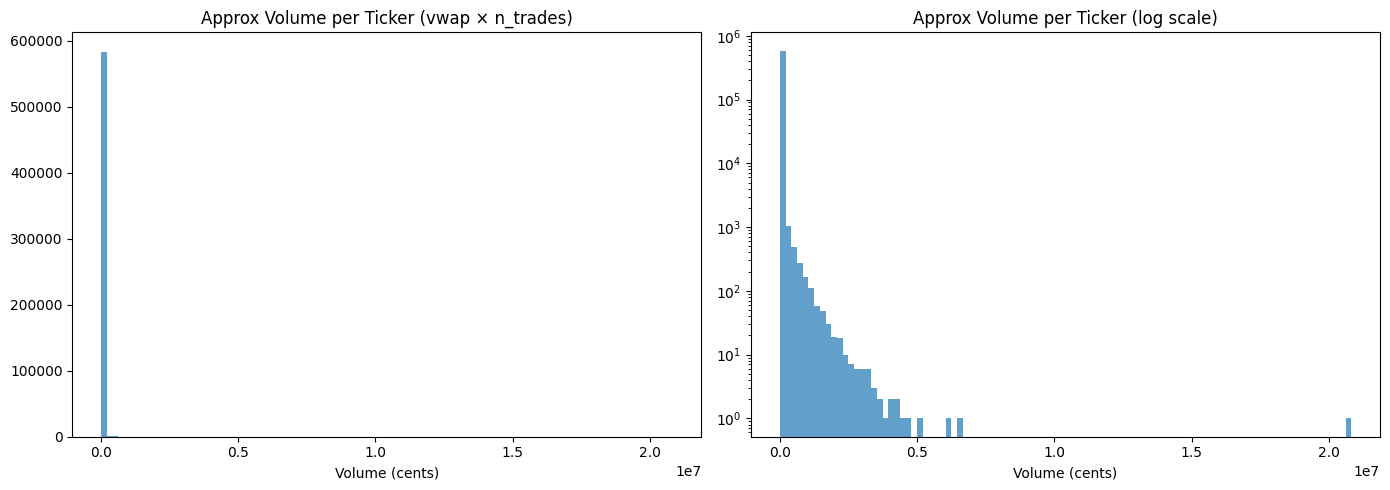

count    5.860250e+05
mean     5.416999e+03
std      6.098351e+04
min      0.000000e+00
25%      5.000000e+00
50%      6.900000e+01
75%      9.650000e+02
max      2.082266e+07
Name: approx_volume, dtype: float64


In [35]:
vol_per_ticker = df.groupby("ticker")["approx_volume"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(vol_per_ticker, bins=100, edgecolor="none", alpha=0.7)
axes[0].set_title("Approx Volume per Ticker (vwap × n_trades)")
axes[0].set_xlabel("Volume (cents)")

axes[1].hist(vol_per_ticker, bins=100, edgecolor="none", alpha=0.7, log=True)
axes[1].set_title("Approx Volume per Ticker (log scale)")
axes[1].set_xlabel("Volume (cents)")

plt.tight_layout()
plt.show()

print(vol_per_ticker.describe())

## Filter by trading volume
### Do not want poor data from illiquid contracts 

In [36]:
# Filter out bottom 25% by approx volume
vol_per_ticker = df.groupby("ticker")["approx_volume"].sum()
threshold = vol_per_ticker.quantile(0.25)
keep_tickers = vol_per_ticker[vol_per_ticker >= threshold].index
df = df[df["ticker"].isin(keep_tickers)].reset_index(drop=True)
print(f"Kept {len(keep_tickers):,} tickers (dropped {(vol_per_ticker < threshold).sum():,}), threshold: {threshold:.0f}")
print(f"New shape: {df.shape}")

Kept 448,641 tickers (dropped 137,384), threshold: 5
New shape: (21767819, 6)


In [ ]:

print(f"Shape: {df.shape}")
print(f"Unique tickers: {df['ticker'].nunique():,}")
print(f"Date range: {df['created_time'].min()} → {df['created_time'].max()}")
print(f"\nBasic stats:")
df[["last_yes_price", "vwap_yes", "n_trades"]].describe()

Shape: (21767819, 6)
Unique tickers: 448,641
Date range: 2021-06-30 20:09:00+00:00 → 2025-11-25 22:00:00+00:00

Column dtypes:
ticker                         object
created_time      datetime64[ns, UTC]
last_yes_price                float64
vwap_yes                      float64
n_trades                        int64
approx_volume                 float64
dtype: object

Null counts:
ticker            0
created_time      0
last_yes_price    0
vwap_yes          0
n_trades          0
approx_volume     0
dtype: int64

Basic stats:


,last_yes_price,vwap_yes,n_trades
count,2.176782e+07,2.176782e+07,2.176782e+07
mean,4.150547e+01,4.150467e+01,3.306697e+00
std,2.869069e+01,2.861229e+01,1.165690e+01
min,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.600000e+01,1.600000e+01,1.000000e+00
50%,3.900000e+01,3.900000e+01,1.000000e+00
75%,6.300000e+01,6.300000e+01,3.000000e+00
max,9.900000e+01,9.900000e+01,2.018000e+03


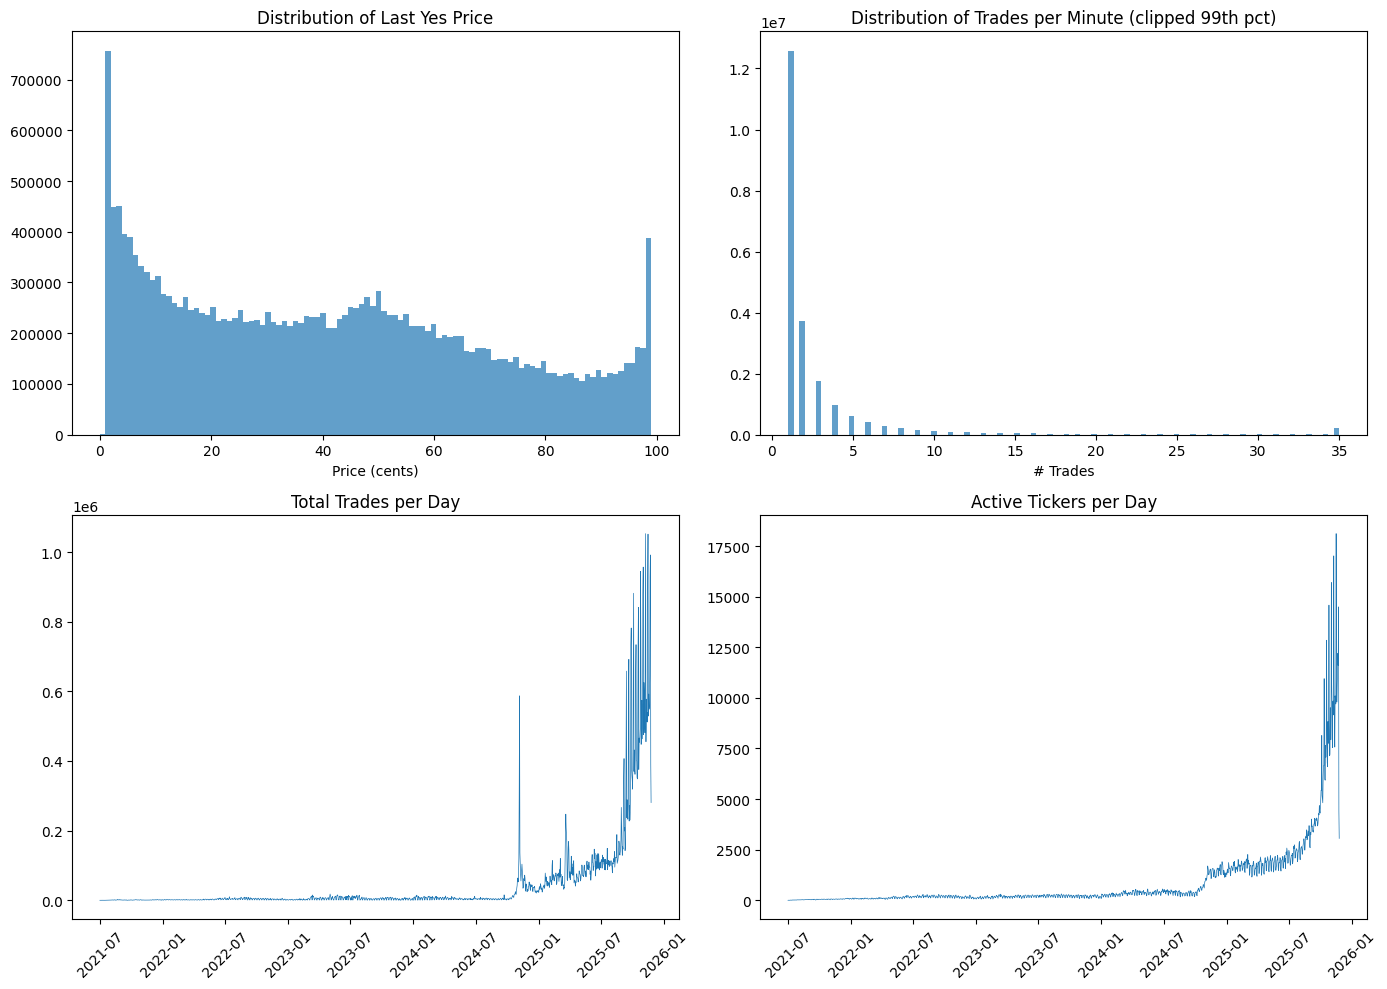

In [38]:
# Distribution of last_yes_price
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["last_yes_price"], bins=100, edgecolor="none", alpha=0.7)
axes[0, 0].set_title("Distribution of Last Yes Price")
axes[0, 0].set_xlabel("Price (cents)")

axes[0, 1].hist(df["n_trades"].clip(upper=df["n_trades"].quantile(0.99)), bins=100, edgecolor="none", alpha=0.7)
axes[0, 1].set_title("Distribution of Trades per Minute (clipped 99th pct)")
axes[0, 1].set_xlabel("# Trades")

# Trades per day
daily = df.groupby(df["created_time"].dt.date)["n_trades"].sum()
axes[1, 0].plot(daily.index, daily.values, lw=0.5)
axes[1, 0].set_title("Total Trades per Day")
axes[1, 0].tick_params(axis="x", rotation=45)

# Active tickers per day
active = df.groupby(df["created_time"].dt.date)["ticker"].nunique()
axes[1, 1].plot(active.index, active.values, lw=0.5)
axes[1, 1].set_title("Active Tickers per Day")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Lets look at things in terms of returns

In [39]:
df["returns"] = df.groupby("ticker")["last_yes_price"].pct_change()
print(df[["ticker", "created_time", "last_yes_price", "returns"]].head(10))

      ticker              created_time  last_yes_price   returns
0  -23MAR-T2 2023-03-12 21:40:00+00:00            15.0       NaN
1  -23MAR-T2 2023-03-12 22:10:00+00:00            20.0  0.333333
2  -23MAR-T2 2023-03-12 22:11:00+00:00            21.0  0.050000
3  -23MAR-T2 2023-03-13 17:28:00+00:00            20.0 -0.047619
4  -23MAR-T2 2023-03-13 20:03:00+00:00            13.0 -0.350000
5  -23MAR-T2 2023-03-14 03:46:00+00:00            12.0 -0.076923
6  -23MAR-T2 2023-03-14 18:06:00+00:00             7.0 -0.416667
7  -23MAR-T2 2023-03-14 18:36:00+00:00             7.0  0.000000
8  -23MAR-T2 2023-03-14 20:36:00+00:00             7.0  0.000000
9  -23MAR-T2 2023-03-15 01:44:00+00:00             7.0  0.000000


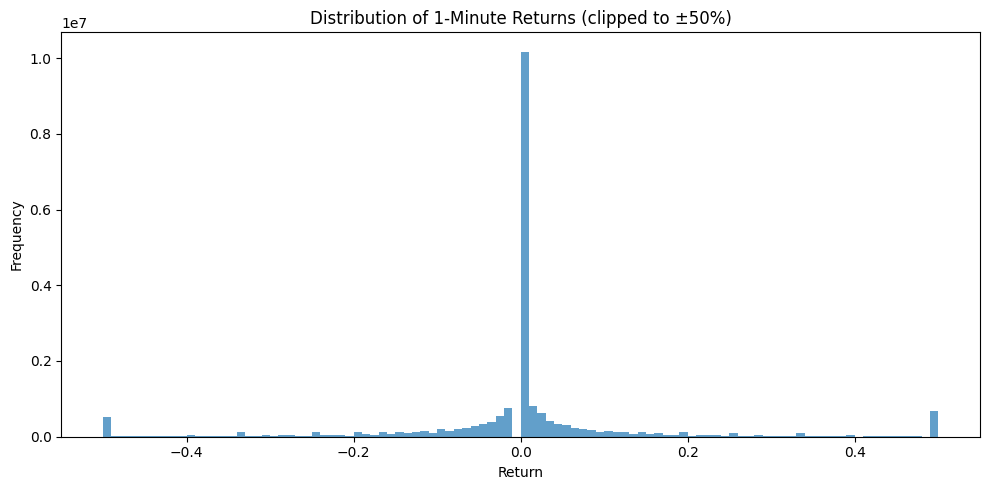

In [40]:
# Plot histogram of returns
plt.figure(figsize=(10, 5))
plt.hist(df["returns"].dropna().clip(-0.5, 0.5), bins=100, edgecolor="none", alpha=0.7)
plt.title("Distribution of 1-Minute Returns (clipped to ±50%)")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [41]:
# Describe returns

print(df["returns"].describe())

c:\Users\ablan\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    2.131812e+07
mean              inf
std               NaN
min     -1.000000e+00
25%     -1.162791e-02
50%      0.000000e+00
75%      1.234568e-02
max               inf
Name: returns, dtype: float64
